In [2]:
%pip install torch

   ---------------------------------------- 0.0/122.1 MB ? eta -:--:--
   -- ------------------------------------- 6.8/122.1 MB 38.8 MB/s eta 0:00:03
   ----- ---------------------------------- 16.3/122.1 MB 41.2 MB/s eta 0:00:03
   ------- -------------------------------- 24.1/122.1 MB 40.6 MB/s eta 0:00:03
   ----------- ---------------------------- 34.3/122.1 MB 42.4 MB/s eta 0:00:03
   ------------- -------------------------- 42.2/122.1 MB 41.2 MB/s eta 0:00:02
   ---------------- ----------------------- 50.3/122.1 MB 41.0 MB/s eta 0:00:02
   ------------------- -------------------- 60.0/122.1 MB 41.7 MB/s eta 0:00:02
   ---------------------- ----------------- 68.2/122.1 MB 41.0 MB/s eta 0:00:02
   ------------------------ --------------- 75.5/122.1 MB 41.0 MB/s eta 0:00:02
   --------------------------- ------------ 82.6/122.1 MB 39.4 MB/s eta 0:00:02
   ------------------------------ --------- 91.8/122.1 MB 39.7 MB/s eta 0:00:01
   ------------------------------- ------- 100.1/1

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
# Celda 1 — Verificación de entorno
import sys
 
print(f"Python: {sys.version}")
 
for paquete in ["torch", "sklearn", "matplotlib", "numpy"]:
 try:
    modulo = __import__(paquete)
    print(f"{paquete}: {modulo.__version__} ✓")
 except ImportError:
    print(f"{paquete} no instalado — ejecuta: pip install {paquete}")

Python: 3.14.6 (tags/v3.14.6:c63aec6, Jun 10 2026, 10:26:10) [MSC v.1944 64 bit (AMD64)]
torch: 2.13.0+cpu ✓
sklearn: 1.9.0 ✓
matplotlib: 3.11.1 ✓
numpy: 2.5.1 ✓


Muestras: 1797 | Píxeles por imagen: 64 | Clases: 10


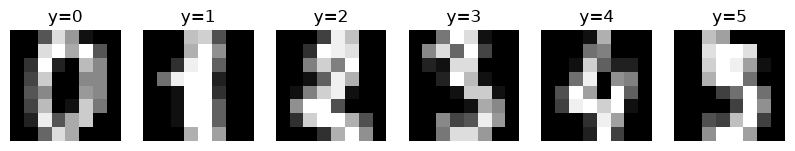

In [4]:
# Celda 2 — Cargar y explorar el dataset
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt

datos = load_digits()
X, y = datos.data, datos.target

print(f"Muestras: {X.shape[0]} | Píxeles por imagen: {X.shape[1]} | Clases: {len(set(y))}")

fig, axes = plt.subplots(1, 6, figsize=(10, 2))
for i, ax in enumerate(axes):
    ax.imshow(datos.images[i], cmap="gray")
    ax.set_title(f"y={y[i]}")
    ax.axis("off")
plt.show()

In [5]:
# Celda 3 — Partición train / validation / test
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
 
X_train, X_temp, y_train, y_temp = train_test_split(
 X, y, test_size=0.3, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
 X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)
 
escalador = StandardScaler()
X_train_esc = escalador.fit_transform(X_train)
X_val_esc = escalador.transform(X_val)
X_test_esc = escalador.transform(X_test)
 
print(f"Train: {len(X_train)} | Validation: {len(X_val)} | Test: {len(X_test)}")

Train: 1257 | Validation: 270 | Test: 270


In [6]:
# Celda 4 — Modelo baseline (sin redes neuronales)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
 
baseline = LogisticRegression(max_iter=1000, random_state=42)
baseline.fit(X_train_esc, y_train)
 
pred_test_baseline = baseline.predict(X_test_esc)
acc_baseline = accuracy_score(y_test, pred_test_baseline)
 
print(f"Accuracy (regresión logística) en test: {acc_baseline:.3f}")

Accuracy (regresión logística) en test: 0.985


In [9]:
# Celda 5 — Arquitectura del MLP
import torch
import torch.nn as nn

torch.manual_seed(42)

class MLPDigits(nn.Module):
    def __init__(self):
        super().__init__()
        self.red = nn.Sequential(
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 10)  # 10 clases — sin activación
        )

    def forward(self, x):
        return self.red(x)

modelo = MLPDigits()
print(modelo)

MLPDigits(
  (red): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [10]:
# Celda 6 — Entrenamiento
import torch.optim as optim
 
X_train_t = torch.tensor(X_train_esc, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t = torch.tensor(X_val_esc, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)
 
criterio = nn.CrossEntropyLoss()
optimizador = optim.Adam(modelo.parameters(), lr=0.001)
 
mejor_val_loss = float("inf")
paciencia, epocas_sin_mejora = 15, 0
historial = {"train_loss": [], "val_loss": []}
 
for epoch in range(200):
    modelo.train()
    optimizador.zero_grad()
    salida = modelo(X_train_t)
    perdida_train = criterio(salida, y_train_t)
    perdida_train.backward() # backpropagation: calcula los gradientes
    optimizador.step() # actualiza los pesos con Adam
 
    modelo.eval()
    with torch.no_grad():
        salida_val = modelo(X_val_t)
        perdida_val = criterio(salida_val, y_val_t)
 
    historial["train_loss"].append(perdida_train.item())
    historial["val_loss"].append(perdida_val.item())
 
    if perdida_val.item() < mejor_val_loss:
        mejor_val_loss = perdida_val.item()
        epocas_sin_mejora = 0
        mejores_pesos = {k: v.clone() for k, v in modelo.state_dict().items()}
    else:
        epocas_sin_mejora += 1
 
    if epocas_sin_mejora >= paciencia:
        print(f"Early stopping en epoch {epoch} (sin mejora en {paciencia} epochs)")
    break
modelo.load_state_dict(mejores_pesos) # restaurar los pesos del mejor punto de
#validación

<All keys matched successfully>

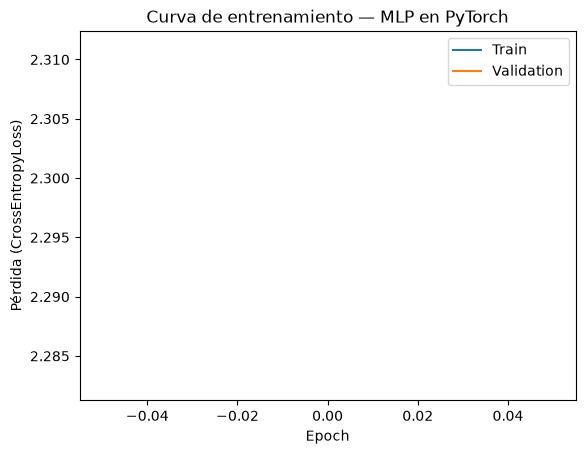

In [13]:
# Celda 7 — Curva de pérdida
plt.plot(historial["train_loss"], label="Train")
plt.plot(historial["val_loss"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Pérdida (CrossEntropyLoss)")
plt.title("Curva de entrenamiento — MLP en PyTorch")
plt.legend()
plt.show()

In [12]:
# Celda 9 — Matriz de confusión del MLP
import matplotlib.pyplot as plt
 
matriz = confusion_matrix(y_test, pred_test_mlp)
plt.imshow(matriz, cmap="Blues")
plt.colorbar()
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión — MLP (test)")
plt.xticks(range(10))
plt.yticks(range(10))
plt.show()

NameError: name 'confusion_matrix' is not defined